# Day 05  Ghép kết quả thành một bộ output hoàn chỉnh

[Open in Colab](https://colab.research.google.com/github/ketnoimaytinh797-dotcom/EGFR-Radiomics-MiniBootcamp/blob/main/book/day05.ipynb)

[Slide của buổi này](_static/slides/day05_slides.pptx)

## Mục tiêu bài học

- Đọc lại output của bốn buổi trước
- Ghép bảng và hình thành một gói kết quả
- Viết đoạn tóm tắt kết quả ngắn
- Chuẩn bị cách đọc số liệu khi nói về báo cáo

## Nội dung

Buổi cuối không thêm thuật toán mới.  
Buổi cuối dùng code để gom kết quả, nhìn lại từng phần và viết ra phần tóm tắt ngắn gọn.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

GITHUB_USER = "ketnoimaytinh797-dotcom"
REPO_NAME = "EGFR-Radiomics-MiniBootcamp"
BRANCH = "main"

def read_csv_demo(filename):
    local_candidates = [
        Path("data") / filename,
        Path("../data") / filename,
        Path(filename),
    ]
    for path in local_candidates:
        if path.exists():
            return pd.read_csv(path)
    url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}/data/{filename}"
    return pd.read_csv(url)


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 160

root_candidates = [Path("outputs"), Path("../book/_static/results"), Path("_static/results")]
for p in root_candidates:
    if p.exists():
        base_results = p
        break
else:
    base_results = Path("../book/_static/results")

output_dir = Path("outputs/day05")
output_dir.mkdir(parents=True, exist_ok=True)
base_results


PosixPath('outputs')

## Bước 1  Đọc lại output của các buổi trước


In [3]:
day01_overall = pd.read_csv(base_results / "day01" / "table1_overall.csv")
day02_roi = pd.read_csv(base_results / "day02" / "roi_performance_table.csv")
day03_cv = pd.read_csv(base_results / "day03" / "cv_auc_table.csv")
day03_boot = pd.read_csv(base_results / "day03" / "bootstrap_auc_values.csv")
day04_pathway = pd.read_csv(base_results / "day04" / "pathway_delta_table.csv")

day01_overall.head(), day02_roi.head(), day04_pathway.head()


(                  Chi so  Gia tri
 0           So benh nhan    200.0
 1        Tuoi trung binh     60.4
 2     Do lech chuan tuoi     14.0
 3    Ty le EGFR dot bien     45.5
 4  Kich thuoc u trung vi     35.6,
      ROI    AUC  Sensitivity  Specificity  TN  FP  FN  TP
 0  ring1  0.815        0.391        0.778  21   6  14   9
 1  ring3  0.747        0.522        0.852  23   4  11  12
 2  ring5  0.747        0.435        0.815  22   5  13  10
 3  intra  0.694        0.391        0.852  23   4  14   9,
       Pathway  n_mut  Median P mut  ...  Mean P wt  Delta mean P  p value
 0        PI3K     24         0.596  ...      0.395         0.181    0.028
 1  DNA_repair     19         0.489  ...      0.432         0.104    0.370
 2  Cell_cycle     24         0.498  ...      0.459         0.011    0.851
 3     RTK_RAS     22         0.442  ...      0.461         0.006    0.961
 4        TP53     28         0.386  ...      0.481        -0.041    0.680
 
 [5 rows x 9 columns])

## Bước 2  Chọn các số quan trọng nhất


In [4]:
n_patient = int(day01_overall.loc[day01_overall["Chi so"] == "So benh nhan", "Gia tri"].iloc[0])
egfr_rate = float(day01_overall.loc[day01_overall["Chi so"] == "Ty le EGFR dot bien", "Gia tri"].iloc[0])
best_roi = day02_roi.iloc[0]["ROI"]
best_auc = float(day02_roi.iloc[0]["AUC"])
cv_mean = float(day03_cv["AUC"].mean())
ci_low = float(day03_boot["bootstrap_auc"].quantile(0.025))
ci_high = float(day03_boot["bootstrap_auc"].quantile(0.975))
top_pathway = day04_pathway.iloc[0]["Pathway"]
top_delta = float(day04_pathway.iloc[0]["Delta median P"])

key_table = pd.DataFrame([
    ["So benh nhan", n_patient],
    ["Ty le EGFR dot bien", egfr_rate],
    ["ROI tot nhat", best_roi],
    ["AUC chia minh hoa", round(best_auc, 3)],
    ["Mean AUC cua 5 fold", round(cv_mean, 3)],
    ["CI thap", round(ci_low, 3)],
    ["CI cao", round(ci_high, 3)],
    ["Pathway noi bat", top_pathway],
    ["Delta median P", round(top_delta, 3)],
], columns=["Chi so", "Gia tri"])

key_table.to_csv(output_dir / "key_numbers_table.csv", index=False)
key_table


,Chi so,Gia tri
0,So benh nhan,200
1,Ty le EGFR dot bien,45.5
2,ROI tot nhat,ring1
3,AUC chia minh hoa,0.815
4,Mean AUC cua 5 fold,0.81
5,CI thap,0.686
6,CI cao,0.925
7,Pathway noi bat,PI3K
8,Delta median P,0.232


## Bước 3  Viết một đoạn tóm tắt ngắn

Đây là kiểu đoạn văn ngắn để gắn vào slide báo cáo hoặc phần kết quả.


In [5]:
summary_day05 = (
    f"Cohort demo co {n_patient} benh nhan va ty le EGFR dot bien la {egfr_rate:.1f} phan tram. "
    f"Trong lan chia minh hoa, ROI {best_roi} dat AUC {best_auc:.3f}. "
    f"Cross validation 5 fold cho mean AUC {cv_mean:.3f} va bootstrap 95 CI tu {ci_low:.3f} den {ci_high:.3f}. "
    f"Trong subset NGS, {top_pathway} co delta median P {top_delta:.3f}."
)

(output_dir / "summary_demo.txt").write_text(summary_day05, encoding="utf-8")
summary_day05


'Cohort demo co 200 benh nhan va ty le EGFR dot bien la 45.5 phan tram. Trong lan chia minh hoa, ROI ring1 dat AUC 0.815. Cross validation 5 fold cho mean AUC 0.810 va bootstrap 95 CI tu 0.686 den 0.925. Trong subset NGS, PI3K co delta median P 0.232.'

## Bước 4  Tạo một hình nhắc lại flow 5 buổi


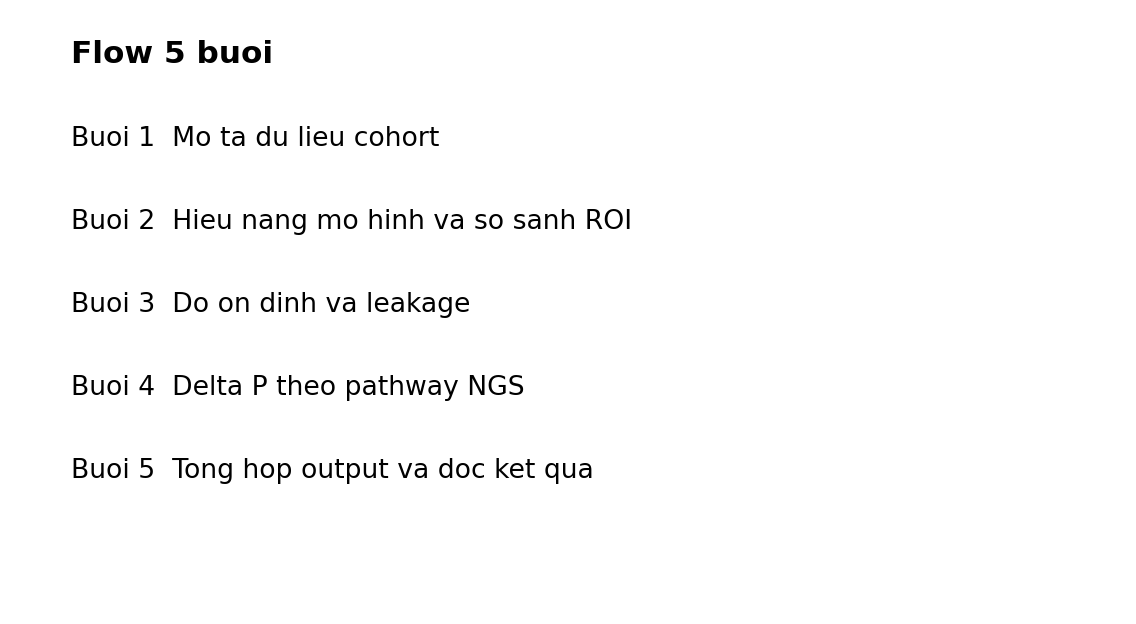

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.axis("off")

lines = [
    "Flow 5 buoi",
    "Buoi 1  Mo ta du lieu cohort",
    "Buoi 2  Hieu nang mo hinh va so sanh ROI",
    "Buoi 3  Do on dinh va leakage",
    "Buoi 4  Delta P theo pathway NGS",
    "Buoi 5  Tong hop output va doc ket qua",
]

for i, line in enumerate(lines):
    ax.text(0.05, 0.92 - i * 0.14, line, fontsize=14 if i == 0 else 12, weight="bold" if i == 0 else None)

fig.tight_layout()
fig.savefig(output_dir / "flow_5days.png")
plt.show()


## Bước 5  Kiểm tra thư mục output cuối cùng


In [7]:
sorted([p.name for p in output_dir.iterdir()])


['flow_5days.png', 'key_numbers_table.csv', 'summary_demo.txt']

## Tự kiểm tra

- Có biết chọn bốn đến năm con số nào để nói trong một phút không
- Có biết vì sao phải đặt AUC cạnh CV và bootstrap không
- Có biết vì sao phần pathway chỉ là một lớp diễn giải thêm không
- Có thể mở thư mục output cuối và đọc từng file không
